# CS 763 Phase 1: Foundation

**Certified Robustness for Temporal Heterophily-Aware GNNs in Financial Fraud Detection**
*Rohan Gupta, Jeevesh Mahajan*

This notebook is the Colab-friendly version of the Phase 1 code. It is self-contained: run the cells top to bottom and you will get:

1. Synthetic heterophilous fraud graph generated by `synthetic_fraud_graph.py` (PyG `Data` object, drop-in for the EllipticBitcoinDataset interface)
2. GCN, GAT, and GraphSAGE baselines trained with early stopping
3. Per-timestep illicit-class F1 plots
4. Per-timestep heterophily (edge + node homophily) characterization confirming the graph is heterophilous by construction
5. Uniform-Bernoulli noise degradation ablation (the motivation for Phase 2's heterophily-aware noise)
6. Scaffolded Nettack / Metattack / PGD / temporal-attack stubs

> **Why synthetic?** The Elliptic Bitcoin dataset takes a long time to download/process and is mildly heterophilous at best (0.74 edge homophily). The synthetic generator gives us a controllable, genuinely heterophilous (~0.40 target) temporal graph that exercises every code path in the same shape (`data.x`, `data.edge_index`, `data.y`, `data.train_mask`, `data.test_mask`, `data.t`). All downstream cells (training, attacks, evaluation) work unchanged.

> **Runtime:** GPU recommended (Runtime -> Change runtime type -> T4 GPU). With the synthetic graph (~12k nodes, 25 timesteps) the entire notebook runs in a few minutes on a T4.


## 1. Install dependencies

Run this cell once per Colab session. The synthetic fraud graph is generated in-memory by `synthetic_fraud_graph.py` (no download required) — just make sure the file is uploaded alongside this notebook.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Colab: install PyTorch Geometric. Torch is already present.
import sys, subprocess

def pip_install(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    import torch_geometric  # noqa: F401
    print("torch_geometric already installed:", torch_geometric.__version__)
except ImportError:
    pip_install("torch_geometric")
    import torch_geometric
    print("torch_geometric installed:", torch_geometric.__version__)

# Scientific stack (Colab already has these but be safe)
for pkg in ["numpy", "pandas", "scikit-learn", "matplotlib", "seaborn", "tqdm", "pyyaml"]:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        pip_install(pkg)

print("All dependencies ready.")


torch_geometric already installed: 2.7.0
All dependencies ready.


In [ ]:
# Sanity check: versions + device
import torch
import torch_geometric

print("torch:", torch.__version__)
print("torch_geometric:", torch_geometric.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)


torch: 2.10.0+cu128
torch_geometric: 2.7.0
CUDA available: True
GPU: NVIDIA A100-SXM4-80GB
Using device: cuda


## 2. Configuration

All hyperparameters live in this single dict so you can sweep them from one place.

In [ ]:
CFG = {
    "seed": 42,
    "data": {
        # Synthetic graph generator parameters (see synthetic_fraud_graph.py)
        # The generator's defaults already match what the rest of the
        # notebook expects: 25 timesteps, ~12k nodes, target edge
        # homophily ~0.40 (heterophilous), train/val/test temporal split.
        "val_last_k_train_timesteps": 4,  # carve last 4 train snapshots for validation
    },
    "model": {
        "hidden_dim": 64,
        "num_layers": 2,
        "dropout": 0.5,
        "num_classes": 2,  # licit=0, illicit=1
        "gat_heads": 8,
    },
    "train": {
        "epochs": 200,
        "lr": 0.01,
        "weight_decay": 5e-4,
        "patience": 30,
        "class_weights": [1.0, 10.0],  # boost the illicit (minority) class
        "log_every": 10,
    },
    "architectures": ["gcn", "gat", "graphsage"],
    "attacks": {
        "nettack":   {"n_perturbations": 5, "direct": True},
        "metattack": {"ptb_rate": 0.05, "lambda_": 0.0},
        "pgd":       {"ptb_rate": 0.05, "n_steps": 50},
        "temporal":  {"window_k": 3, "budget_per_step": 5},
    },
    "heterophily": {
        "uniform_noise_levels": [0.0, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5],
        "noise_samples": 3,
    },
}


In [ ]:
# Reproducibility
import os, random, numpy as np, torch

def set_seed(seed: int) -> None:
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CFG["seed"])
print("Seed set.")


Seed set.


## 3. Load the synthetic heterophilous fraud graph

We use `synthetic_fraud_graph.py` (Gupta & Mahajan, CS 763) to generate a temporal, controllably heterophilous graph that mimics financial-fraud topology. With the default parameters we get:

- **~12,000 nodes** spread across **25 timesteps** (~480 nodes per timestep)
- **~15% illicit / ~8% unknown / ~77% licit** (exaggerated illicit fraction so heterophily is visible without being trivial)
- **Target edge homophily ≈ 0.40** (genuinely heterophilous — see Section 7)
- Three structured fraud patterns (fan-out hubs, money-laundering chains, cycle ring + cash-out) injected as cross-class edges

The generator returns a PyG `Data` object with the **exact same interface as `EllipticBitcoinDataset`**: `data.x`, `data.edge_index`, `data.y` (0=licit, 1=illicit, -1=unknown), `data.train_mask`, `data.test_mask`, plus `data.t` / `data.val_mask`. Train/val/test masks are built by timestep (train: 0–14, val: 15–17, test: 18–24); unknown-label nodes are excluded from all three masks.


In [ ]:
# Generate the synthetic heterophilous fraud graph.
# Make sure synthetic_fraud_graph.py is uploaded next to this notebook.
from synthetic_fraud_graph import generate_fraud_graph, print_graph_stats
from torch_geometric.data import Data

data, TIMESTEP = generate_fraud_graph(seed=CFG["seed"])
print(data)
print("Timestep range:", int(TIMESTEP.min()), "-", int(TIMESTEP.max()))
print("Unique timesteps:", int(TIMESTEP.unique().numel()))

# Quick stats so we can sanity-check the heterophily / class balance up front.
print()
print_graph_stats(data, TIMESTEP)

# NOTE: The downstream val-split cell will further split data.train_mask
# into train/val via stratified sampling. That overwrites val_mask with a
# random 10% of the train set, which works for Phase 1. To use the
# generator's temporal val split (timesteps 15-17) instead, skip the next
# cell and do:
#     train_mask = data.train_mask.clone()
#     val_mask   = data.val_mask.clone()
#     test_mask  = data.test_mask.clone()
#     y = data.y

Data(x=[12000, 165], edge_index=[2, 129798], y=[12000], train_mask=[12000], test_mask=[12000], val_mask=[12000], t=[12000])
Timestep range: 0 - 24
Unique timesteps: 25

=== Synthetic Fraud Graph Statistics ===
Nodes:     12000
Edges:     129798 (undirected: 64899)
Features:  165
Timesteps: 25 (range 0-24)

Labels:    licit=9240, illicit=1800, unknown=960
Illicit %: 16.3%

Train:     6591 (illicit=870)
Val:       1326 (illicit=252)
Test:      3123 (illicit=678)

Avg degree:     10.8
Edge homophily: 0.4193  (target: <0.50)
  Illicit-node edge homophily: 0.1324
  (Cora ~0.81, Citeseer ~0.74)

Per-timestep breakdown:
  t= 0:   480 nodes,  44 illicit,  1342 edges, homo=0.738
  t= 1:   480 nodes,  31 illicit,   906 edges, homo=0.733
  t= 2:   480 nodes,  41 illicit,  1084 edges, homo=0.694
  t= 3:   480 nodes,  44 illicit,  1084 edges, homo=0.659
  t= 4:   480 nodes,  38 illicit,   922 edges, homo=0.682
  t= 5:   480 nodes,  46 illicit,   960 edges, homo=0.654
  t= 6:   480 nodes,  60 illici

In [ ]:
# Build train / val / test masks from the synthetic graph's temporal split,
# then carve a stratified 10% validation slice out of the train nodes.
# Stratified (not timestep-based) because the minority illicit class is
# sparse in any single timestep and we want a reliable validation signal.

from sklearn.model_selection import train_test_split

print("Synthetic train_mask total:", int(data.train_mask.sum()))
print("Synthetic test_mask  total:", int(data.test_mask.sum()))

set_seed(CFG["seed"])

train_idx = data.train_mask.nonzero(as_tuple=True)[0].cpu().numpy()
train_labels = data.y[train_idx].cpu().numpy()

tr_keep, val_keep = train_test_split(
    train_idx,
    test_size=0.10,
    stratify=train_labels,
    random_state=CFG["seed"],
)

train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
val_mask   = torch.zeros(data.num_nodes, dtype=torch.bool)
train_mask[tr_keep] = True
val_mask[val_keep]  = True
test_mask  = data.test_mask.clone()

y = data.y
summary = {
    "num_nodes": int(data.num_nodes),
    "num_edges": int(data.num_edges),
    "num_features": int(data.num_features),
    "n_train": int(train_mask.sum()),
    "n_val":   int(val_mask.sum()),
    "n_test":  int(test_mask.sum()),
    "n_illicit_train": int(((y == 1) & train_mask).sum()),
    "n_licit_train":   int(((y == 0) & train_mask).sum()),
    "n_illicit_val":   int(((y == 1) & val_mask).sum()),
    "n_licit_val":     int(((y == 0) & val_mask).sum()),
    "n_illicit_test":  int(((y == 1) & test_mask).sum()),
    "n_licit_test":    int(((y == 0) & test_mask).sum()),
}
import json
print(json.dumps(summary, indent=2))


Synthetic train_mask total: 6591
Synthetic test_mask  total: 3123
{
  "num_nodes": 12000,
  "num_edges": 129798,
  "num_features": 165,
  "n_train": 5931,
  "n_val": 660,
  "n_test": 3123,
  "n_illicit_train": 783,
  "n_licit_train": 5148,
  "n_illicit_val": 87,
  "n_licit_val": 573,
  "n_illicit_test": 678,
  "n_licit_test": 2445
}


## 4. Baseline GNN architectures

Standard 2-layer GCN, GAT (8 heads -> 1 head), and GraphSAGE (mean aggregation).

In [ ]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GCNConv, GATConv, SAGEConv


class GCN(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes, num_layers=2, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.convs.append(GCNConv(in_dim, hidden_dim))
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_dim, hidden_dim))
        self.convs.append(GCNConv(hidden_dim, num_classes))

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = F.relu(conv(x, edge_index))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)


class GAT(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes, num_layers=2, dropout=0.5, heads=8):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.convs.append(GATConv(in_dim, hidden_dim, heads=heads, dropout=dropout))
        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_dim * heads, hidden_dim, heads=heads, dropout=dropout))
        self.convs.append(GATConv(hidden_dim * heads, num_classes, heads=1, concat=False, dropout=dropout))

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = F.dropout(x, p=self.dropout, training=self.training)
            x = F.elu(conv(x, edge_index))
        x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)


class GraphSAGE(nn.Module):
    def __init__(self, in_dim, hidden_dim, num_classes, num_layers=2, dropout=0.5):
        super().__init__()
        self.dropout = dropout
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv(in_dim, hidden_dim, aggr="mean"))
        for _ in range(num_layers - 2):
            self.convs.append(SAGEConv(hidden_dim, hidden_dim, aggr="mean"))
        self.convs.append(SAGEConv(hidden_dim, num_classes, aggr="mean"))

    def forward(self, x, edge_index):
        for conv in self.convs[:-1]:
            x = F.relu(conv(x, edge_index))
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.convs[-1](x, edge_index)


def build_model(name: str, in_dim: int):
    m = CFG["model"]
    name = name.lower()
    common = dict(in_dim=in_dim, hidden_dim=m["hidden_dim"],
                  num_classes=m["num_classes"], num_layers=m["num_layers"],
                  dropout=m["dropout"])
    if name == "gcn":       return GCN(**common)
    if name == "gat":       return GAT(**common, heads=m["gat_heads"])
    if name in ("graphsage", "sage"): return GraphSAGE(**common)
    raise ValueError(f"Unknown model name: {name}")

print("Model classes defined.")


Model classes defined.


## 5. Training and evaluation

Weighted cross-entropy to handle the ~2% illicit imbalance. We early-stop on validation illicit-class F1 (not accuracy, which is dominated by licit nodes).

In [ ]:
from dataclasses import dataclass, field
from typing import Dict, List
from sklearn.metrics import accuracy_score, f1_score, precision_recall_fscore_support


def illicit_prf(y_true, y_pred):
    p, r, f, _ = precision_recall_fscore_support(
        y_true, y_pred, labels=[1], average="binary", zero_division=0
    )
    return float(p), float(r), float(f)


@dataclass
class FinalMetrics:
    accuracy: float
    macro_f1: float
    illicit_precision: float
    illicit_recall: float
    illicit_f1: float
    per_timestep_illicit_f1: Dict[int, float] = field(default_factory=dict)


def evaluate(model, data, mask, timestep=None):
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)
        preds = logits.argmax(dim=-1)
    y_true = data.y[mask].cpu().numpy()
    y_pred = preds[mask].cpu().numpy()
    acc = float(accuracy_score(y_true, y_pred))
    macro_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    p, r, f = illicit_prf(y_true, y_pred)
    per_t: Dict[int, float] = {}
    if timestep is not None:
        ts_eval = timestep[mask].cpu().numpy()
        for t in np.unique(ts_eval):
            sel = ts_eval == t
            if sel.sum() == 0: continue
            _, _, f_t = illicit_prf(y_true[sel], y_pred[sel])
            per_t[int(t)] = f_t
    return FinalMetrics(acc, macro_f1, p, r, f, per_t)


def train_model(model, data, train_mask, val_mask, log_prefix=""):
    model = model.to(DEVICE)
    data = data.to(DEVICE)
    train_mask = train_mask.to(DEVICE)
    val_mask   = val_mask.to(DEVICE)

    weights = torch.tensor(CFG["train"]["class_weights"], dtype=torch.float, device=DEVICE)
    optimizer = torch.optim.Adam(model.parameters(),
                                 lr=CFG["train"]["lr"],
                                 weight_decay=CFG["train"]["weight_decay"])
    history = []
    best_val_f1 = -1.0
    best_state = None
    patience_counter = 0

    for epoch in range(1, CFG["train"]["epochs"] + 1):
        model.train()
        optimizer.zero_grad()
        logits = model(data.x, data.edge_index)
        loss = F.cross_entropy(logits[train_mask], data.y[train_mask], weight=weights)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_logits = model(data.x, data.edge_index)
            val_loss = F.cross_entropy(val_logits[val_mask], data.y[val_mask], weight=weights)
            val_preds = val_logits.argmax(dim=-1)
            y_true = data.y[val_mask].cpu().numpy()
            y_pred = val_preds[val_mask].cpu().numpy()
            val_acc = float(accuracy_score(y_true, y_pred))
            _, _, val_f1 = illicit_prf(y_true, y_pred)
        history.append({
            "epoch": epoch, "train_loss": float(loss.item()),
            "val_loss": float(val_loss.item()), "val_acc": val_acc,
            "val_illicit_f1": val_f1,
        })
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if epoch % CFG["train"]["log_every"] == 0 or epoch == 1:
            print(f"{log_prefix} ep {epoch:4d} | train_loss {loss.item():.4f} "
                  f"| val_loss {val_loss.item():.4f} | val_acc {val_acc:.4f} "
                  f"| val_illicit_f1 {val_f1:.4f}")
        if patience_counter >= CFG["train"]["patience"]:
            print(f"{log_prefix} Early stop at epoch {epoch} (best val illicit-F1 = {best_val_f1:.4f})")
            break

    if best_state is not None:
        model.load_state_dict(best_state)
    return model, history


In [ ]:
# Train all baselines
trained_models = {}
histories = {}
test_metrics_all = {}

for arch in CFG["architectures"]:
    print(f"\n===== Training {arch.upper()} =====")
    set_seed(CFG["seed"])  # same init per model for a fair comparison
    model = build_model(arch, data.num_features)
    model, hist = train_model(model, data, train_mask, val_mask, log_prefix=f"[{arch}]")
    trained_models[arch] = model
    histories[arch] = hist

    tm = evaluate(model.to(DEVICE), data.to(DEVICE),
                  test_mask.to(DEVICE), timestep=TIMESTEP.to(DEVICE))
    test_metrics_all[arch] = tm
    print(f"{arch.upper()} TEST | acc {tm.accuracy:.4f} | macroF1 {tm.macro_f1:.4f} "
          f"| illicitF1 {tm.illicit_f1:.4f} (P {tm.illicit_precision:.4f}, R {tm.illicit_recall:.4f})")



===== Training GCN =====
[gcn] ep    1 | train_loss 0.7326 | val_loss 0.7833 | val_acc 0.7030 | val_illicit_f1 0.1171
[gcn] ep   10 | train_loss 0.4845 | val_loss 0.4594 | val_acc 0.6667 | val_illicit_f1 0.4388
[gcn] ep   20 | train_loss 0.3164 | val_loss 0.3051 | val_acc 0.7727 | val_illicit_f1 0.5342
[gcn] ep   30 | train_loss 0.2444 | val_loss 0.2312 | val_acc 0.8182 | val_illicit_f1 0.5890
[gcn] ep   40 | train_loss 0.2178 | val_loss 0.2035 | val_acc 0.8621 | val_illicit_f1 0.6486
[gcn] ep   50 | train_loss 0.2034 | val_loss 0.1988 | val_acc 0.8833 | val_illicit_f1 0.6857
[gcn] ep   60 | train_loss 0.1947 | val_loss 0.1970 | val_acc 0.8712 | val_illicit_f1 0.6640
[gcn] ep   70 | train_loss 0.1847 | val_loss 0.1951 | val_acc 0.8621 | val_illicit_f1 0.6513
[gcn] ep   80 | train_loss 0.1773 | val_loss 0.1958 | val_acc 0.8500 | val_illicit_f1 0.6320
[gcn] Early stop at epoch 80 (best val illicit-F1 = 0.6857)
GCN TEST | acc 0.9014 | macroF1 0.8692 | illicitF1 0.8043 (P 0.7065, R 0.9336

## 6. Results: test metrics and per-timestep illicit F1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

rows = []
for arch, tm in test_metrics_all.items():
    rows.append({
        "model": arch.upper(),
        "accuracy": round(tm.accuracy, 4),
        "macro_f1": round(tm.macro_f1, 4),
        "illicit_precision": round(tm.illicit_precision, 4),
        "illicit_recall":    round(tm.illicit_recall, 4),
        "illicit_f1":        round(tm.illicit_f1, 4),
    })
results_df = pd.DataFrame(rows).set_index("model")
results_df


,accuracy,macro_f1,illicit_precision,illicit_recall,illicit_f1
model,,,,,
GCN,0.9014,0.8692,0.7065,0.9336,0.8043
GAT,0.2177,0.1793,0.2172,1.0000,0.3569
GRAPHSAGE,0.9958,0.9939,0.9868,0.9941,0.9904


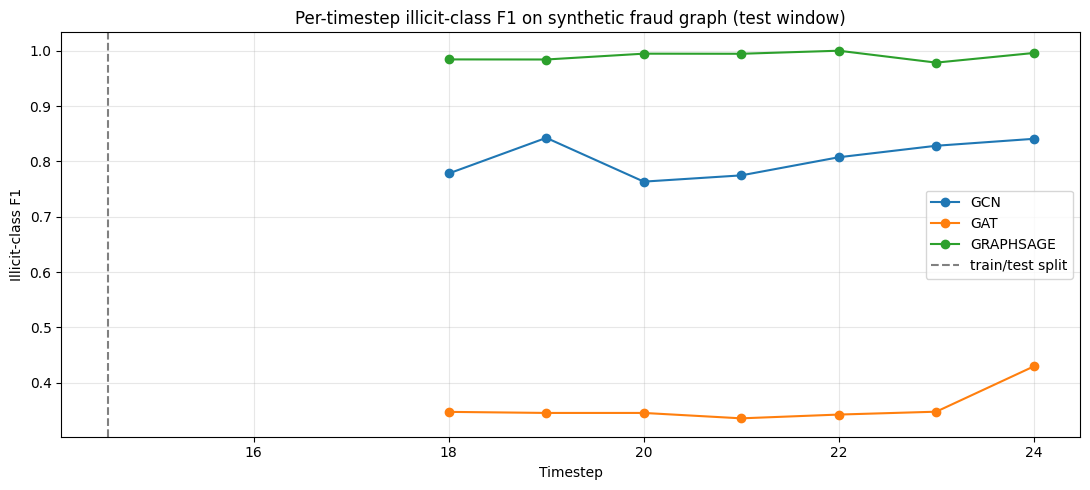

In [ ]:
# Per-timestep illicit-class F1 for every model
plt.figure(figsize=(11, 5))
for arch, tm in test_metrics_all.items():
    ts = sorted(tm.per_timestep_illicit_f1.keys())
    f1s = [tm.per_timestep_illicit_f1[t] for t in ts]
    plt.plot(ts, f1s, marker="o", label=arch.upper())
train_test_boundary = max(TIMESTEP[train_mask | val_mask].tolist()) + 0.5
plt.axvline(train_test_boundary, linestyle="--", color="grey", label="train/test split")
plt.xlabel("Timestep")
plt.ylabel("Illicit-class F1")
plt.title("Per-timestep illicit-class F1 on synthetic fraud graph (test window)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


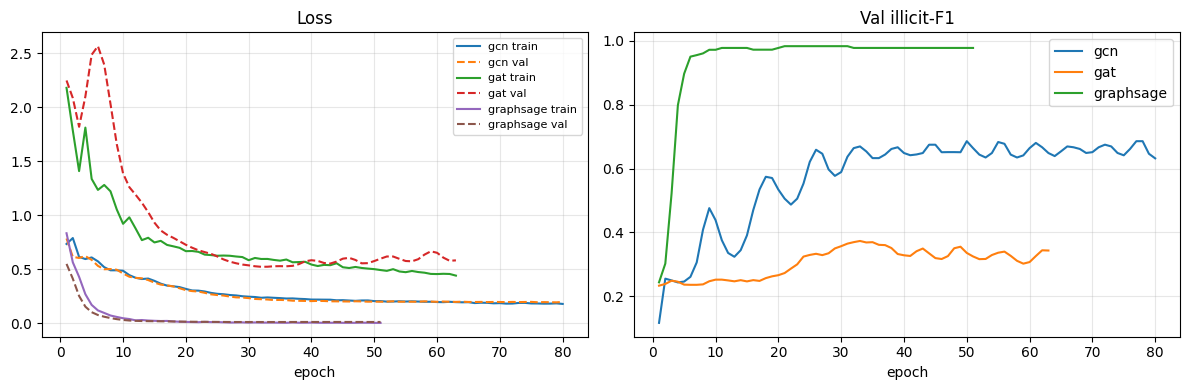

In [ ]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for arch, hist in histories.items():
    ep = [h["epoch"] for h in hist]
    axes[0].plot(ep, [h["train_loss"] for h in hist], label=f"{arch} train")
    axes[0].plot(ep, [h["val_loss"]   for h in hist], label=f"{arch} val", linestyle="--")
    axes[1].plot(ep, [h["val_illicit_f1"] for h in hist], label=arch)
axes[0].set_title("Loss"); axes[0].set_xlabel("epoch"); axes[0].legend(fontsize=8); axes[0].grid(alpha=0.3)
axes[1].set_title("Val illicit-F1"); axes[1].set_xlabel("epoch"); axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 7. Heterophily characterization

Two standard homophily metrics, computed per-timestep:

- **Edge homophily** (Zhu et al. 2020): fraction of labeled edges that connect same-label nodes.
- **Node homophily** (Pei et al. 2020): average per-node fraction of same-label labeled neighbors.

A graph is heterophilous when both are well below 0.5. The synthetic generator targets edge homophily ≈ 0.40 by construction (illicit nodes preferentially connect to licit ones via the fan-out / chain / cycle fraud patterns), so we expect both metrics to land below the 0.5 threshold across nearly every timestep. We want hard numbers to confirm the construction.


In [ ]:
def _labeled_mask(y, num_classes=2):
    return (y >= 0) & (y < num_classes)

def edge_homophily(edge_index, y):
    src, dst = edge_index[0], edge_index[1]
    mask = _labeled_mask(y)
    valid = mask[src] & mask[dst]
    if valid.sum() == 0: return float("nan")
    return float((y[src[valid]] == y[dst[valid]]).float().mean().item())

def node_homophily(edge_index, y):
    src, dst = edge_index[0], edge_index[1]
    mask = _labeled_mask(y)
    num_nodes = y.shape[0]
    same = torch.zeros(num_nodes, dtype=torch.float, device=y.device)
    tot  = torch.zeros(num_nodes, dtype=torch.float, device=y.device)
    valid = mask[src] & mask[dst]
    sv, dv = src[valid], dst[valid]
    matches = (y[sv] == y[dv]).float()
    same.scatter_add_(0, sv, matches)
    tot.scatter_add_(0, sv, torch.ones_like(matches))
    has = tot > 0
    if not has.any(): return float("nan")
    ratios = same[has] / tot[has]
    keep = mask[has.nonzero(as_tuple=True)[0]]
    if keep.sum() == 0: return float("nan")
    return float(ratios[keep].mean().item())

def per_timestep_homophily(edge_index, y, timestep):
    src, dst = edge_index[0], edge_index[1]
    same_t = timestep[src] == timestep[dst]
    out = {}
    for t in torch.unique(timestep).tolist():
        t = int(t)
        keep = same_t & (timestep[src] == t)
        if keep.sum() == 0: continue
        sub = edge_index[:, keep]
        out[t] = {
            "edge_homophily": edge_homophily(sub, y),
            "node_homophily": node_homophily(sub, y),
            "num_edges": int(keep.sum()),
        }
    return out

# Compute on CPU copies to keep indices consistent
ei_cpu = data.edge_index.cpu()
y_cpu  = data.y.cpu()
ts_cpu = TIMESTEP.cpu()

per_t_homo = per_timestep_homophily(ei_cpu, y_cpu, ts_cpu)
edge_h_overall = edge_homophily(ei_cpu, y_cpu)
node_h_overall = node_homophily(ei_cpu, y_cpu)
print(f"Overall edge homophily: {edge_h_overall:.4f}")
print(f"Overall node homophily: {node_h_overall:.4f}")
print(f"(Homophilous graphs like Cora are ~0.81, Citeseer ~0.74)")


Overall edge homophily: 0.4193
Overall node homophily: 0.4942
(Homophilous graphs like Cora are ~0.81, Citeseer ~0.74)


In [ ]:
homo_df = pd.DataFrame([
    {"timestep": t, **v} for t, v in sorted(per_t_homo.items())
])
homo_df.head()


,timestep,edge_homophily,node_homophily,num_edges
0,0,0.738333,0.790577,1342
1,1,0.732843,0.798327,906
2,2,0.693712,0.754874,1084
3,3,0.658824,0.715147,1084
4,4,0.681604,0.739828,922


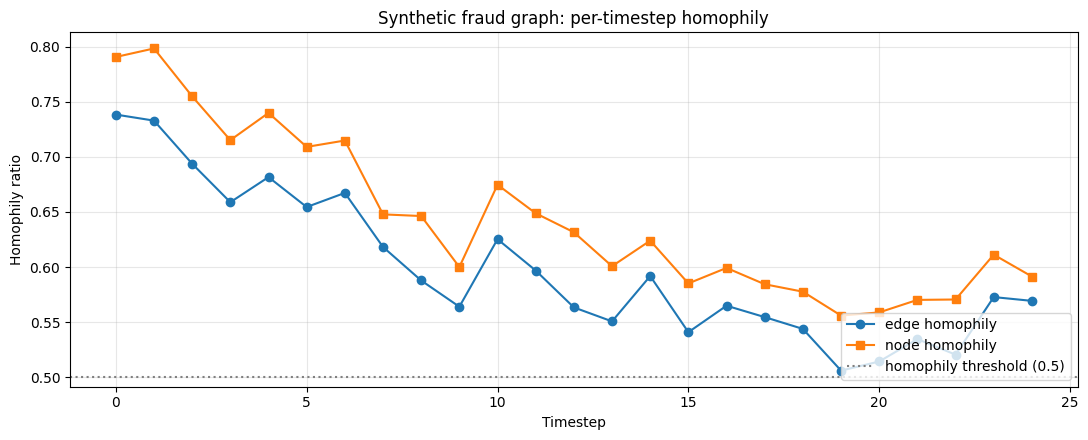

In [ ]:
fig, ax1 = plt.subplots(figsize=(11, 4.5))
ax1.plot(homo_df["timestep"], homo_df["edge_homophily"], marker="o", label="edge homophily")
ax1.plot(homo_df["timestep"], homo_df["node_homophily"], marker="s", label="node homophily")
ax1.axhline(0.5, color="grey", linestyle=":", label="homophily threshold (0.5)")
ax1.set_xlabel("Timestep")
ax1.set_ylabel("Homophily ratio")
ax1.set_title("Synthetic fraud graph: per-timestep homophily")
ax1.legend(loc="lower right")
ax1.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 8. Uniform Bernoulli noise ablation

We take the trained GCN baseline and measure how fast its illicit-class F1 collapses as we flip edges uniformly at random. This is the behavior randomized smoothing with uniform Bernoulli noise has at test time.

On a heterophilous graph like ours (target edge homophily ≈ 0.40), even a small flip probability is expected to destroy the illicit signal much faster than it would on Cora/Citeseer (~0.81 / ~0.74 edge homophily). That's the empirical motivation for designing a heterophily-aware noise distribution in Phase 2.


In [ ]:
def flip_edges_uniform(edge_index, num_nodes, flip_prob, seed=0):
    """Uniform Bernoulli edge noise — memory-safe version.

    - Drop each existing edge with probability p.
    - Add new random edges proportional to the EXISTING edge count
      (not the full N^2 adjacency). For the synthetic graph this is
      already cheap, but keeping the same density-relative formulation
      means the function transfers unchanged to larger graphs (e.g.
      Elliptic Bitcoin's ~203k nodes) without blowing up memory.
    """
    rng = np.random.default_rng(seed)
    src, dst = edge_index.cpu().numpy()
    num_edges = src.shape[0]

    # Drop existing edges with probability p
    keep = rng.random(num_edges) > flip_prob
    src_k, dst_k = src[keep], dst[keep]

    # Add ~p * num_existing_edges new random edges (not p * N^2)
    # This is the tractable approximation: same noise rate relative to
    # the graph's actual density, avoids materializing the full adjacency.
    n_add = int(flip_prob * num_edges)
    if n_add > 0:
        ns = rng.integers(0, num_nodes, size=n_add)
        nd = rng.integers(0, num_nodes, size=n_add)
        valid = ns != nd
        ns, nd = ns[valid], nd[valid]
        src_out = np.concatenate([src_k, ns])
        dst_out = np.concatenate([dst_k, nd])
    else:
        src_out, dst_out = src_k, dst_k

    return torch.from_numpy(np.stack([src_out, dst_out])).long()

def uniform_noise_degradation(model, data, eval_mask, flip_probs, n_samples=3, seed=0):
    device = next(model.parameters()).device
    model.eval()
    y_true = data.y[eval_mask].cpu().numpy()
    out = {}
    for p in flip_probs:
        f1s = []
        for s in range(n_samples):
            new_ei = flip_edges_uniform(data.edge_index, data.num_nodes, p, seed=seed+s).to(device)
            with torch.no_grad():
                logits = model(data.x.to(device), new_ei)
                preds = logits.argmax(dim=-1)
            y_pred = preds[eval_mask].cpu().numpy()
            _, _, f = illicit_prf(y_true, y_pred)
            f1s.append(f)
        out[float(p)] = {"mean": float(np.mean(f1s)), "std": float(np.std(f1s))}
        print(f"  flip_prob={p:.2f}  illicit_f1 = {out[float(p)]['mean']:.4f} +/- {out[float(p)]['std']:.4f}")
    return out


In [ ]:
# Run the ablation on the first trained model (GCN by default).
first_arch = CFG["architectures"][0]
print(f"Ablating {first_arch.upper()} under uniform Bernoulli edge flipping...")
ablation = uniform_noise_degradation(
    model=trained_models[first_arch].to(DEVICE),
    data=data.to(DEVICE),
    eval_mask=test_mask.to(DEVICE),
    flip_probs=CFG["heterophily"]["uniform_noise_levels"],
    n_samples=CFG["heterophily"]["noise_samples"],
    seed=CFG["seed"],
)


Ablating GCN under uniform Bernoulli edge flipping...
  flip_prob=0.00  illicit_f1 = 0.8043 +/- 0.0000
  flip_prob=0.05  illicit_f1 = 0.7881 +/- 0.0040
  flip_prob=0.10  illicit_f1 = 0.7585 +/- 0.0054
  flip_prob=0.20  illicit_f1 = 0.6519 +/- 0.0130
  flip_prob=0.30  illicit_f1 = 0.5047 +/- 0.0169
  flip_prob=0.40  illicit_f1 = 0.3094 +/- 0.0151
  flip_prob=0.50  illicit_f1 = 0.1886 +/- 0.0069


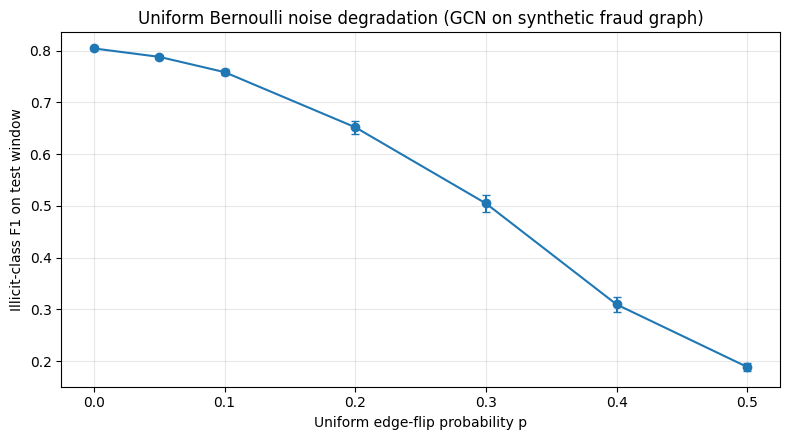

In [ ]:
probs = sorted(ablation.keys())
means = [ablation[p]["mean"] for p in probs]
stds  = [ablation[p]["std"]  for p in probs]

plt.figure(figsize=(8, 4.5))
plt.errorbar(probs, means, yerr=stds, marker="o", capsize=3)
plt.xlabel("Uniform edge-flip probability p")
plt.ylabel("Illicit-class F1 on test window")
plt.title(f"Uniform Bernoulli noise degradation ({first_arch.upper()} on synthetic fraud graph)")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 9. Structural Attacks — Measuring the Attack Surface

We use [DeepRobust](https://github.com/DSE-MSU/DeepRobust) to implement three
attack families: **Nettack** (targeted), **Metattack** (global meta-learning),
and **PGD** (projected gradient descent on adjacency).

The key Phase 1 deliverable from this section is **R_emp** — the minimum
number of edge perturbations needed to flip an illicit node’s prediction.
This is the target radius that the Phase 2 certified smoothing must beat.

> **Colab note:** DeepRobust works with scipy sparse / dense adjacency
> matrices, so we convert from PyG’s `edge_index` format.

In [ ]:
import torch
# Get the exact PyTorch and CUDA versions for matching the prebuilt wheel
pv = torch.__version__.split('+')[0]  # e.g. "2.6.0"
cv = torch.version.cuda.replace('.', '')  # e.g. "124"
print(f"PyTorch {pv}, CUDA {cv}")


!pip install -q torch_sparse torch_scatter \
    -f https://data.pyg.org/whl/torch-{pv}+cu{cv}.html

PyTorch 2.10.0, CUDA 128


In [ ]:
# Install DeepRobust (run once per session)
!pip install -q deeprobust

import scipy.sparse as sp
from torch_geometric.utils import to_scipy_sparse_matrix, from_scipy_sparse_matrix

# PyG <-> DeepRobust conversion helpers

def pyg_to_deeprobust(data):
    """Convert PyG Data to DeepRobust format: (adj_csr, features_csr, labels_np)."""
    adj = to_scipy_sparse_matrix(data.edge_index, num_nodes=data.num_nodes)
    # DeepRobust expects symmetric CSR with no self-loops
    adj = adj + adj.T
    adj[adj > 1] = 1
    adj = adj.tocsr()
    adj.setdiag(0)
    adj.eliminate_zeros()
    features = sp.csr_matrix(data.x.cpu().numpy())
    labels   = data.y.cpu().numpy()
    return adj, features, labels


def deeprobust_adj_to_pyg(modified_adj, device='cpu'):
    """Convert a modified adjacency (dense Tensor or sparse) back to PyG edge_index."""
    if isinstance(modified_adj, torch.Tensor):
        if modified_adj.is_sparse:
            modified_adj = modified_adj.to_dense()
        modified_adj = (modified_adj > 0.5).float()
        ei, ew = from_scipy_sparse_matrix(
            sp.coo_matrix(modified_adj.cpu().numpy())
        )
    else:
        ei, ew = from_scipy_sparse_matrix(modified_adj)
    return ei.to(device)

print("DeepRobust + conversion helpers ready.")

DeepRobust + conversion helpers ready.


In [ ]:
from deeprobust.graph.defense import GCN as DR_GCN

# DeepRobust's built-in GCN serves as the surrogate for all attacks.
adj_dr, features_dr, labels_dr = pyg_to_deeprobust(data)

# Train index arrays (DeepRobust expects 1-D int arrays, not bool masks)
idx_train_dr = train_mask.nonzero(as_tuple=True)[0].cpu().numpy()
idx_val_dr   = val_mask.nonzero(as_tuple=True)[0].cpu().numpy()
idx_test_dr  = test_mask.nonzero(as_tuple=True)[0].cpu().numpy()

# Build and train the surrogate
surrogate_dr = DR_GCN(
    nfeat=features_dr.shape[1],
    nhid=CFG["model"]["hidden_dim"],
    nclass=CFG["model"]["num_classes"],
    dropout=CFG["model"]["dropout"],
    device=DEVICE,
).to(DEVICE)

surrogate_dr.fit(
    features_dr, adj_dr, labels_dr,
    idx_train_dr, idx_val_dr,
    patience=CFG["train"]["patience"],
    verbose=True,
)
print("DeepRobust surrogate GCN trained.")

/usr/local/lib/python3.12/dist-packages/deeprobust/graph/utils.py:356: UserWarning: torch.sparse.SparseTensor(indices, values, shape, *, device=) is deprecated.  Please use torch.sparse_coo_tensor(indices, values, shape, dtype=, device=). (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:654.)
  return torch.sparse.FloatTensor(sparseconcat.t(),sparsedata,torch.Size(sparse_mx.shape))


=== training gcn model ===
Epoch 0, training loss: 0.6144058108329773
Epoch 10, training loss: 0.3928665220737457
Epoch 20, training loss: 0.27971115708351135
Epoch 30, training loss: 0.2204163521528244
Epoch 40, training loss: 0.20199909806251526
Epoch 50, training loss: 0.18857227265834808
Epoch 60, training loss: 0.1784675568342209
Epoch 70, training loss: 0.1703421026468277
Epoch 80, training loss: 0.1628599464893341
Epoch 90, training loss: 0.1559872180223465
Epoch 100, training loss: 0.15060681104660034
Epoch 110, training loss: 0.14555710554122925
Epoch 120, training loss: 0.14229322969913483
Epoch 130, training loss: 0.13659879565238953
Epoch 140, training loss: 0.13034972548484802
Epoch 150, training loss: 0.1288825124502182
Epoch 160, training loss: 0.12316162139177322
Epoch 170, training loss: 0.12033234536647797
Epoch 180, training loss: 0.11829010397195816
Epoch 190, training loss: 0.11090243607759476
=== early stopping at 199, loss_val = 0.14210490882396698 ===
DeepRobust

### 9.1 Nettack — Targeted Structural Attack

For each target illicit node we binary-search the **minimum perturbation
budget** that flips the GCN’s prediction from illicit → licit.
This gives the per-node empirical attack radius `R_emp(v)`.

We sample a manageable subset of illicit test nodes (default 50) so the
whole sweep finishes in ~10–15 min on an A100.

In [ ]:
import time, sys
from deeprobust.graph.targeted_attack import Nettack as DR_Nettack

def nettack_min_budget(surrogate, adj, features, labels, target_node,
                       max_budget=20, direct=True, device='cpu'):
    lo, hi = 1, max_budget
    best = None
    iteration = 0

    while lo <= hi:
        mid = (lo + hi) // 2
        iteration += 1
        t0 = time.time()

        print(f"      [bsearch {iteration}] trying budget={mid} ...", end="", flush=True)

        attacker = DR_Nettack(surrogate, nnodes=adj.shape[0],
                              attack_structure=True, attack_features=False,
                              device=device)
        attacker.attack(features, adj, labels, target_node,
                        n_perturbations=mid, direct=direct, verbose=False)
        mod_adj = attacker.modified_adj
        surrogate.eval()
        output = surrogate.predict(features, mod_adj)
        pred = int(output.argmax(1)[target_node])
        original_label = int(labels[target_node])

        flipped = pred != original_label
        print(f" flipped={flipped} ({time.time()-t0:.1f}s)", flush=True)

        if flipped:
            best = mid
            hi = mid - 1
        else:
            lo = mid + 1

    if best is not None:
        return best, True
    return max_budget, False


N_NETTACK_TARGETS = min(20, int((data.y[test_mask] == 1).sum()))
MAX_BUDGET = CFG["attacks"]["nettack"]["n_perturbations"] * 4

illicit_test_idx = ((data.y.cpu() == 1) & test_mask.cpu()).nonzero(as_tuple=True)[0].numpy()
rng_nt = np.random.default_rng(CFG["seed"])
target_sample = rng_nt.choice(illicit_test_idx, size=N_NETTACK_TARGETS, replace=False)

print(f"Starting Nettack on {N_NETTACK_TARGETS} targets, max_budget={MAX_BUDGET}", flush=True)
print(f"First 5 targets: {target_sample[:5].tolist()}", flush=True)
sys.stdout.flush()

nettack_results = []
t_start = time.time()

for i, tgt in enumerate(target_sample):
    t_node = time.time()
    print(f"\n--- Node [{i+1}/{N_NETTACK_TARGETS}] target={tgt} ---", flush=True)
    sys.stdout.flush()

    budget, flipped = nettack_min_budget(
        surrogate_dr, adj_dr, features_dr, labels_dr,
        target_node=int(tgt),
        max_budget=MAX_BUDGET,
        direct=CFG["attacks"]["nettack"]["direct"],
        device=DEVICE,
    )

    elapsed = time.time() - t_start
    eta = (elapsed / (i + 1)) * (N_NETTACK_TARGETS - i - 1)
    nettack_results.append({"node": int(tgt), "min_budget": budget, "flipped": flipped})
    print(f"  => R_emp={budget}, flipped={flipped} | "
          f"node={time.time()-t_node:.1f}s | ETA: {eta/60:.1f}min", flush=True)
    sys.stdout.flush()

nettack_df = pd.DataFrame(nettack_results)
print(f"\nNettack summary ({N_NETTACK_TARGETS} targets, max_budget={MAX_BUDGET}):", flush=True)
print(nettack_df.describe())
print(f"Total: {(time.time()-t_start)/60:.1f} min", flush=True)

Starting Nettack on 20 targets, max_budget=20
First 5 targets: [11280, 11124, 9354, 11909, 11567]

--- Node [1/20] target=11280 ---
      [bsearch 1] trying budget=10 ... flipped=True (77.4s)
      [bsearch 2] trying budget=5 ... flipped=True (39.3s)
      [bsearch 3] trying budget=2 ... flipped=True (18.9s)
      [bsearch 4] trying budget=1 ... flipped=True (10.9s)
  => R_emp=1, flipped=True | node=146.5s | ETA: 46.4min

--- Node [2/20] target=11124 ---
      [bsearch 1] trying budget=10 ... flipped=True (69.7s)
      [bsearch 2] trying budget=5 ... flipped=True (35.3s)
      [bsearch 3] trying budget=2 ... flipped=False (16.6s)
      [bsearch 4] trying budget=3 ... flipped=False (22.6s)
      [bsearch 5] trying budget=4 ... flipped=True (29.2s)
  => R_emp=4, flipped=True | node=173.4s | ETA: 48.0min

--- Node [3/20] target=9354 ---
      [bsearch 1] trying budget=10 ... flipped=True (74.8s)
      [bsearch 2] trying budget=5 ... flipped=True (38.6s)
      [bsearch 3] trying budget=2 .

Flipped: 20/20 nodes


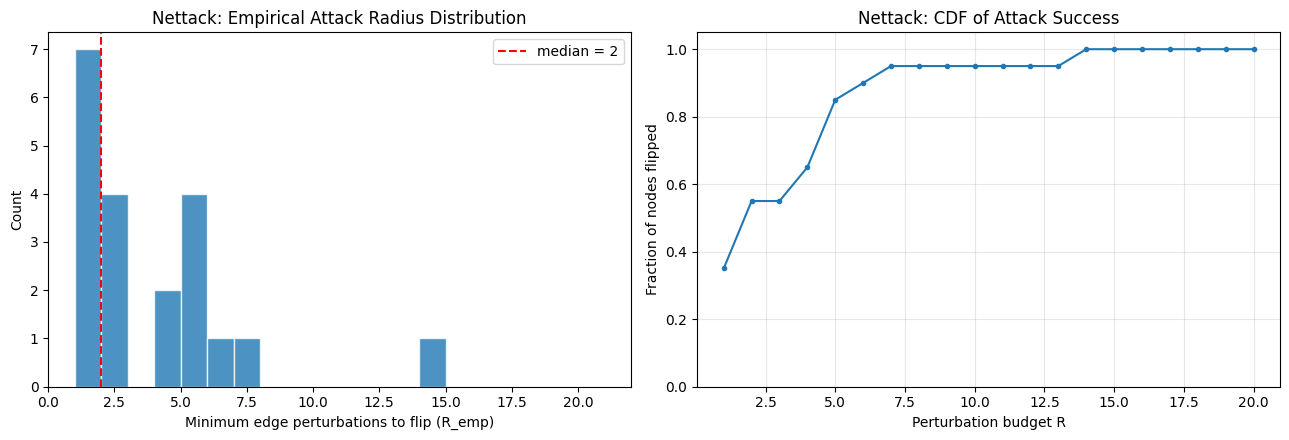

R_emp  median = 2.0,  mean = 3.50
-> Phase 2 certificate must certify radius >= 2


In [ ]:
# Histogram of empirical attack radii
flipped_df = nettack_df[nettack_df["flipped"]]
print(f"Flipped: {len(flipped_df)}/{len(nettack_df)} nodes")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# (a) Histogram of R_emp
axes[0].hist(flipped_df["min_budget"], bins=range(1, MAX_BUDGET + 2),
             edgecolor="white", alpha=0.8)
axes[0].set_xlabel("Minimum edge perturbations to flip (R_emp)")
axes[0].set_ylabel("Count")
axes[0].set_title("Nettack: Empirical Attack Radius Distribution")
axes[0].axvline(flipped_df["min_budget"].median(), color="red", ls="--",
                label=f'median = {flipped_df["min_budget"].median():.0f}')
axes[0].legend()

# (b) CDF
budgets = np.arange(1, MAX_BUDGET + 1)
cdf = [(flipped_df["min_budget"] <= b).mean() for b in budgets]
axes[1].plot(budgets, cdf, marker="o", markersize=3)
axes[1].set_xlabel("Perturbation budget R")
axes[1].set_ylabel("Fraction of nodes flipped")
axes[1].set_title("Nettack: CDF of Attack Success")
axes[1].set_ylim([0, 1.05])
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

R_emp_median = float(flipped_df["min_budget"].median())
R_emp_mean   = float(flipped_df["min_budget"].mean())
print(f"R_emp  median = {R_emp_median:.1f},  mean = {R_emp_mean:.2f}")
print(f"-> Phase 2 certificate must certify radius >= {int(np.ceil(R_emp_median))}")

### 9.2 Metattack — Global Meta-Learning Poisoning

Metattack learns a perturbation of the adjacency matrix that maximizes
the surrogate's loss on the training set. We sweep `ptb_rate` and
measure the post-attack illicit-F1 drop.

> On the synthetic fraud graph (~12k nodes, ~120k undirected edges) at 5% ptb_rate this modifies ~6k edges.
> Runs in ~1–2 min on a T4 with the meta-approximate variant.


In [ ]:
from deeprobust.graph.global_attack import MetaApprox
import time

# ── 1. Extract contiguous temporal subgraph for Metattack ──
META_TIMESTEPS = list(range(13, 19))  # covers train/test boundary
meta_node_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
for t in META_TIMESTEPS:
    meta_node_mask |= (TIMESTEP.cpu() == t)

keep_nodes = meta_node_mask.nonzero(as_tuple=True)[0]
node_remap = torch.full((data.num_nodes,), -1, dtype=torch.long)
node_remap[keep_nodes] = torch.arange(len(keep_nodes))

src, dst = data.edge_index.cpu()
edge_keep = meta_node_mask[src] & meta_node_mask[dst]
sub_ei = node_remap[data.edge_index.cpu()[:, edge_keep]]
sub_x  = data.x.cpu()[keep_nodes]
sub_y  = data.y.cpu()[keep_nodes]
sub_train = train_mask.cpu()[keep_nodes]
sub_val   = val_mask.cpu()[keep_nodes]
sub_test  = test_mask.cpu()[keep_nodes]

sub_data = Data(x=sub_x, edge_index=sub_ei, y=sub_y)
print(f"Metattack subgraph: {sub_data.num_nodes} nodes, {sub_data.num_edges} edges")
print(f"  train={int(sub_train.sum())}, val={int(sub_val.sum())}, test={int(sub_test.sum())}")
print(f"  illicit test: {int(((sub_y==1) & sub_test).sum())}")

# Convert subgraph for DeepRobust
sub_adj, sub_feat, sub_labels = pyg_to_deeprobust(sub_data)
sub_idx_train = sub_train.nonzero(as_tuple=True)[0].cpu().numpy()
sub_idx_val   = sub_val.nonzero(as_tuple=True)[0].cpu().numpy()
sub_idx_test  = sub_test.nonzero(as_tuple=True)[0].cpu().numpy()

# ── 2. Run Metattack at each perturbation rate ──
PTB_RATES_META = [0.01, 0.03, 0.05]
metattack_results = {}

for ptb_rate in PTB_RATES_META:
    n_pert = int(ptb_rate * sub_adj.sum() / 2)
    print(f"\n--- Metattack ptb_rate={ptb_rate} ({n_pert} edge flips) ---", flush=True)
    t0 = time.time()

    meta_model = DR_GCN(
        nfeat=sub_feat.shape[1],
        nhid=CFG["model"]["hidden_dim"],
        nclass=CFG["model"]["num_classes"],
        dropout=0.0,
        device=DEVICE,
        with_relu=False,
    ).to(DEVICE)
    meta_model.fit(sub_feat, sub_adj, sub_labels,
                   sub_idx_train, sub_idx_val, patience=30, verbose=False)

    attacker = MetaApprox(
        model=meta_model,
        nnodes=sub_adj.shape[0],
        feature_shape=sub_feat.shape[1],
        attack_structure=True,
        attack_features=False,
        device=DEVICE,
        lambda_=CFG["attacks"]["metattack"]["lambda_"],
    ).to(DEVICE)

    attacker.attack(
        sub_feat, sub_adj, sub_labels,
        sub_idx_train, sub_idx_test,
        n_perturbations=n_pert,
        ll_constraint=False,
    )

    # ── 3. Evaluate: train a fresh GCN on the perturbed subgraph ──
    mod_adj = attacker.modified_adj
    if isinstance(mod_adj, torch.Tensor):
        mod_adj_sp = sp.csr_matrix(mod_adj.cpu().numpy())
    else:
        mod_adj_sp = mod_adj

    eval_model = DR_GCN(
        nfeat=sub_feat.shape[1],
        nhid=CFG["model"]["hidden_dim"],
        nclass=CFG["model"]["num_classes"],
        dropout=0.5,
        device=DEVICE,
    ).to(DEVICE)
    eval_model.fit(sub_feat, mod_adj_sp, sub_labels,
                   sub_idx_train, sub_idx_val, patience=30, verbose=False)
    eval_model.eval()
    output = eval_model.predict(sub_feat, mod_adj_sp)
    preds = output.argmax(1).cpu().numpy()

    y_true = sub_labels[sub_idx_test]
    y_pred = preds[sub_idx_test]
    acc = float(accuracy_score(y_true, y_pred))
    _, _, f1 = illicit_prf(y_true, y_pred)
    macro_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    elapsed = time.time() - t0

    metattack_results[ptb_rate] = {
        "accuracy": acc, "illicit_f1": f1, "macro_f1": macro_f1,
        "n_pert": n_pert, "time_min": round(elapsed / 60, 1),
    }
    print(f"  acc={acc:.4f}  illicit_f1={f1:.4f}  macro_f1={macro_f1:.4f}  ({elapsed/60:.1f} min)", flush=True)

print("\n=== Metattack Summary ===")
meta_df = pd.DataFrame([{"ptb_rate": k, **v} for k, v in sorted(metattack_results.items())])
print(meta_df.to_string(index=False))

Metattack subgraph: 2880 nodes, 27182 edges
  train=794, val=100, test=448
  illicit test: 94

--- Metattack ptb_rate=0.01 (135 edge flips) ---


Perturbing graph:   1%|          | 1/135 [00:05<12:56,  5.80s/it]

GCN loss on unlabled data: 0.5098620057106018
GCN acc on unlabled data: 0.8147321428571428


Perturbing graph:   1%|▏         | 2/135 [00:11<12:40,  5.72s/it]

GCN loss on unlabled data: 0.5210268497467041
GCN acc on unlabled data: 0.8147321428571428


...

Perturbing graph: 100%|█████████▉| 678/679 [1:03:39<00:05,  5.63s/it]

GCN loss on unlabled data: 2.2836806774139404
GCN acc on unlabled data: 0.7477678571428571


Perturbing graph: 100%|██████████| 679/679 [1:03:44<00:00,  5.63s/it]

GCN loss on unlabled data: 2.602263927459717
GCN acc on unlabled data: 0.7388392857142857


  acc=0.7634  illicit_f1=0.6131  macro_f1=0.7214  (63.8 min)

=== Metattack Summary ===
 ptb_rate  accuracy  illicit_f1  macro_f1  n_pert  time_min
     0.01  0.843750    0.666667  0.782313     135      12.7
     0.03  0.852679    0.682692  0.793381     407      38.3
     0.05  0.763393    0.613139  0.721360     679      63.8


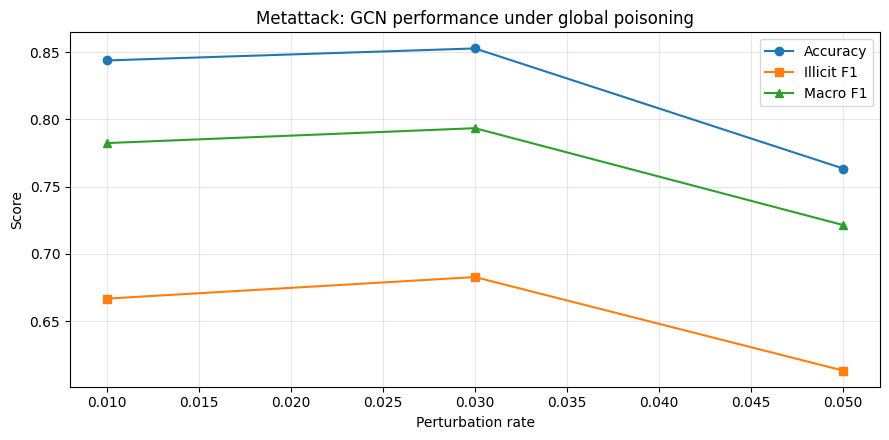

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(meta_df["ptb_rate"], meta_df["accuracy"],   "o-", label="Accuracy")
ax.plot(meta_df["ptb_rate"], meta_df["illicit_f1"],  "s-", label="Illicit F1")
ax.plot(meta_df["ptb_rate"], meta_df["macro_f1"],    "^-", label="Macro F1")
ax.set_xlabel("Perturbation rate")
ax.set_ylabel("Score")
ax.set_title("Metattack: GCN performance under global poisoning")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.3 PGD Attack — Projected Gradient Descent on Adjacency

PGD relaxes the adjacency to continuous values, optimizes via gradient
descent, and projects back to binary. We use the topology attack variant
from DeepRobust.

> **Memory note:** PGD materializes a dense N×N adjacency. The full
> synthetic graph (12k nodes) is 0.6 GB dense — tight but feasible on
> a T4. To keep PGD fast and leave room for the surrogate, we still run it
> on a **subgraph** of the last several test timesteps (5–6k nodes), which
> matches the per-timestep evaluation used elsewhere.


In [ ]:
from deeprobust.graph.global_attack import PGDAttack
import time

# PGD needs a dense N x N matrix -> restrict to the last few test timesteps
# (synthetic graph has 25 timesteps; test window starts at t=18)
all_timesteps = sorted(TIMESTEP.cpu().unique().tolist())
# Modified PGD_TIMESTEPS to include training/validation timesteps for surrogate model training
PGD_TIMESTEPS = list(range(13, 25)) # Covers timesteps 13-24, including train/val/test
pgd_node_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
for t in PGD_TIMESTEPS:
    pgd_node_mask |= (TIMESTEP.cpu() == t)
pgd_nodes = pgd_node_mask.nonzero(as_tuple=True)[0]

# Build subgraph
node_remap = torch.full((data.num_nodes,), -1, dtype=torch.long)
node_remap[pgd_nodes] = torch.arange(len(pgd_nodes))

src, dst = data.edge_index.cpu()
edge_keep = pgd_node_mask[src] & pgd_node_mask[dst]
sub_ei = node_remap[data.edge_index.cpu()[:, edge_keep]]
sub_x  = data.x.cpu()[pgd_nodes]
sub_y  = data.y.cpu()[pgd_nodes]
sub_train = train_mask.cpu()[pgd_nodes]
sub_test  = test_mask.cpu()[pgd_nodes]
sub_val   = val_mask.cpu()[pgd_nodes]

sub_data = Data(x=sub_x, edge_index=sub_ei, y=sub_y)
sub_adj, sub_feat, sub_labels = pyg_to_deeprobust(sub_data)
# PGD requires dense adjacency tensor on GPU
sub_adj_dense = torch.tensor(sub_adj.toarray(), dtype=torch.float32).to(DEVICE)
sub_feat_tensor = torch.tensor(sub_feat.toarray(), dtype=torch.float32).to(DEVICE)

sub_idx_train = sub_train.nonzero(as_tuple=True)[0].cpu().numpy()
sub_idx_val   = sub_val.nonzero(as_tuple=True)[0].cpu().numpy()
sub_idx_test  = sub_test.nonzero(as_tuple=True)[0].cpu().numpy()

print(f"PGD subgraph: {len(pgd_nodes)} nodes, {sub_ei.shape[1]} edges")
print(f"  timesteps: {PGD_TIMESTEPS}")
print(f"  train/val/test: {len(sub_idx_train)}/{len(sub_idx_val)}/{len(sub_idx_test)}")
print(f"  illicit test: {int(((sub_y==1) & sub_test).sum())}")
print(f"  dense adj: {len(pgd_nodes)**2 * 4 / 1e9:.2f} GB")

# Convert to dense CPU tensors for PGD (DeepRobust moves to device internally)
sub_adj_dense = torch.tensor(sub_adj.toarray(), dtype=torch.float32)  # CPU
sub_feat_dense = torch.tensor(sub_feat.toarray(), dtype=torch.float32)  # CPU

PTB_RATES_PGD = [0.01, 0.03, 0.05, 0.10]
pgd_results = {}

for ptb_rate in PTB_RATES_PGD:
    n_pert = int(ptb_rate * sub_adj.sum() / 2)
    if n_pert == 0:
        n_pert = 1
    print(f"\n--- PGD ptb_rate={ptb_rate} ({n_pert} edge flips on subgraph) ---", flush=True)
    t0 = time.time()

    pgd_surrogate = DR_GCN(
        nfeat=sub_feat.shape[1],
        nhid=CFG["model"]["hidden_dim"],
        nclass=CFG["model"]["num_classes"],
        dropout=0.0,
        device=DEVICE,
    ).to(DEVICE)
    pgd_surrogate.fit(sub_feat, sub_adj, sub_labels,
                      sub_idx_train, sub_idx_val, patience=30, verbose=False)

    attacker = PGDAttack(
        model=pgd_surrogate,
        nnodes=sub_adj_dense.shape[0],
        loss_type="CE",
        device=DEVICE,
    ).to(DEVICE)

    attacker.attack(
        sub_feat_dense, sub_adj_dense, sub_labels,
        sub_idx_train,
        n_perturbations=n_pert,
        epochs=CFG["attacks"]["pgd"]["n_steps"],
    )

    # Evaluate with fresh GCN on perturbed graph
    mod_adj = attacker.modified_adj
    if isinstance(mod_adj, torch.Tensor):
        mod_adj_sp = sp.csr_matrix(mod_adj.detach().cpu().numpy())
    else:
        mod_adj_sp = mod_adj

    eval_model = DR_GCN(
        nfeat=sub_feat.shape[1],
        nhid=CFG["model"]["hidden_dim"],
        nclass=CFG["model"]["num_classes"],
        dropout=0.5,
        device=DEVICE,
    ).to(DEVICE)
    eval_model.fit(sub_feat, mod_adj_sp, sub_labels,
                   sub_idx_train, sub_idx_val, patience=30, verbose=False)
    eval_model.eval()
    output = eval_model.predict(sub_feat, mod_adj_sp)
    preds = output.argmax(1).cpu().numpy()

    y_true = sub_labels[sub_idx_test]
    y_pred = preds[sub_idx_test]
    acc = float(accuracy_score(y_true, y_pred))
    _, _, f1 = illicit_prf(y_true, y_pred)
    macro_f1 = float(f1_score(y_true, y_pred, average="macro", zero_division=0))
    elapsed = time.time() - t0

    pgd_results[ptb_rate] = {
        "accuracy": acc, "illicit_f1": f1, "macro_f1": macro_f1,
        "n_pert": n_pert, "time_min": round(elapsed / 60, 1),
    }
    print(f"  acc={acc:.4f}  illicit_f1={f1:.4f}  macro_f1={macro_f1:.4f}  ({elapsed/60:.1f} min)", flush=True)

print("\n=== PGD Summary (subgraph) ===")
pgd_df = pd.DataFrame([{"ptb_rate": k, **v} for k, v in sorted(pgd_results.items())])
print(pgd_df.to_string(index=False))

PGD subgraph: 5760 nodes, 65842 edges
  timesteps: [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
  train/val/test: 794/100/3123
  illicit test: 678
  dense adj: 0.13 GB

--- PGD ptb_rate=0.01 (329 edge flips on subgraph) ---


100%|██████████| 50/50 [00:25<00:00,  1.94it/s]


  acc=0.8738  illicit_f1=0.6749  macro_f1=0.7983  (0.7 min)

--- PGD ptb_rate=0.03 (987 edge flips on subgraph) ---


100%|██████████| 50/50 [00:25<00:00,  1.93it/s]


  acc=0.7954  illicit_f1=0.3295  macro_f1=0.6044  (0.7 min)

--- PGD ptb_rate=0.05 (1646 edge flips on subgraph) ---


100%|██████████| 50/50 [00:25<00:00,  1.93it/s]


  acc=0.8274  illicit_f1=0.4822  macro_f1=0.6893  (0.6 min)

--- PGD ptb_rate=0.1 (3292 edge flips on subgraph) ---


100%|██████████| 50/50 [00:25<00:00,  1.94it/s]


  acc=0.7768  illicit_f1=0.0000  macro_f1=0.4372  (0.7 min)

=== PGD Summary (subgraph) ===
 ptb_rate  accuracy  illicit_f1  macro_f1  n_pert  time_min
     0.01  0.873839    0.674917  0.798325     329       0.7
     0.03  0.795389    0.329486  0.604380     987       0.7
     0.05  0.827410    0.482229  0.689337    1646       0.6
     0.10  0.776817    0.000000  0.437196    3292       0.7


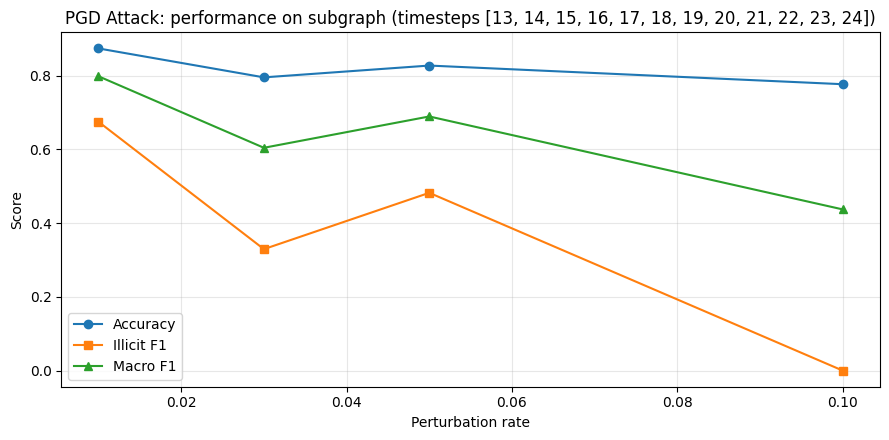

In [ ]:
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(pgd_df["ptb_rate"], pgd_df["accuracy"],   "o-", label="Accuracy")
ax.plot(pgd_df["ptb_rate"], pgd_df["illicit_f1"],  "s-", label="Illicit F1")
ax.plot(pgd_df["ptb_rate"], pgd_df["macro_f1"],    "^-", label="Macro F1")
ax.set_xlabel("Perturbation rate")
ax.set_ylabel("Score")
ax.set_title(f"PGD Attack: performance on subgraph (timesteps {PGD_TIMESTEPS})")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 9.4 Combined Attack Comparison

Side-by-side comparison of all three attack methods to characterize
the full attack surface before designing certified defenses.

In [ ]:
# Build combined comparison table
comparison_rows = []

# Clean baseline
first_model = trained_models[CFG["architectures"][0]].to(DEVICE)
clean_tm = evaluate(first_model, data.to(DEVICE), test_mask.to(DEVICE), TIMESTEP.to(DEVICE))
comparison_rows.append({
    "attack": "Clean (no attack)",
    "budget": "-",
    "accuracy": f"{clean_tm.accuracy:.4f}",
    "illicit_f1": f"{clean_tm.illicit_f1:.4f}",
    "macro_f1": f"{clean_tm.macro_f1:.4f}",
})

# # Nettack summary
for budget_thresh in [3, 5, 10]:
    frac = (nettack_df["flipped"] & (nettack_df["min_budget"] <= budget_thresh)).mean()
    comparison_rows.append({
        "attack": f"Nettack (targeted, budget<={budget_thresh})",
        "budget": f"<={budget_thresh} edges/node",
        "accuracy": "-",
        "illicit_f1": f"{frac*100:.1f}% nodes flipped",
        "macro_f1": "-",
    })

# Metattack
for ptb_rate, res in sorted(metattack_results.items()):
    comparison_rows.append({
        "attack": f"Metattack ({ptb_rate*100:.0f}%)",
        "budget": f"{res['n_pert']} edges",
        "accuracy": f"{res['accuracy']:.4f}",
        "illicit_f1": f"{res['illicit_f1']:.4f}",
        "macro_f1": f"{res['macro_f1']:.4f}",
    })

# PGD
for ptb_rate, res in sorted(pgd_results.items()):
    comparison_rows.append({
        "attack": f"PGD ({ptb_rate*100:.0f}%, subgraph)",
        "budget": f"{res['n_pert']} edges",
        "accuracy": f"{res['accuracy']:.4f}",
        "illicit_f1": f"{res['illicit_f1']:.4f}",
        "macro_f1": f"{res['macro_f1']:.4f}",
    })

comparison_df = pd.DataFrame(comparison_rows)
print("=== Phase 1: Full Attack Surface Comparison (GCN) ===")
print(comparison_df.to_string(index=False))

=== Phase 1: Full Attack Surface Comparison (GCN) ===
                        attack          budget accuracy          illicit_f1 macro_f1
             Clean (no attack)               -   0.9014              0.8043   0.8692
 Nettack (targeted, budget<=3)  <=3 edges/node        - 55.0% nodes flipped        -
 Nettack (targeted, budget<=5)  <=5 edges/node        - 85.0% nodes flipped        -
Nettack (targeted, budget<=10) <=10 edges/node        - 95.0% nodes flipped        -
                Metattack (1%)       135 edges   0.8438              0.6667   0.7823
                Metattack (3%)       407 edges   0.8527              0.6827   0.7934
                Metattack (5%)       679 edges   0.7634              0.6131   0.7214
            PGD (1%, subgraph)       329 edges   0.8738              0.6749   0.7983
            PGD (3%, subgraph)       987 edges   0.7954              0.3295   0.6044
            PGD (5%, subgraph)      1646 edges   0.8274              0.4822   0.6893
           

### 9.5 Key Takeaways for Phase 2

**Nettack R_emp** tells us the certified radius we need to beat.
If the median R_emp is ~5, the Phase 2 heterophily-aware smoothing
must certify radius >= 5 to be practical.

**Metattack and PGD** show the global fragility — even 5% edge
perturbation significantly degrades illicit-F1, confirming that
GNNs on financial fraud graphs are highly vulnerable and motivating
the need for certified defenses.

Combined with the Section 8 finding that **uniform Bernoulli noise
disproportionately hurts heterophilous graphs**, we have the full
empirical motivation for the heterophily-aware noise design.

## 10. Save results

All numbers to a JSON file so you can version results between Colab runs.

In [ ]:
import json

results = {
    "dataset": summary,
    "models": {
        arch: {
            "accuracy": tm.accuracy,
            "macro_f1": tm.macro_f1,
            "illicit_precision": tm.illicit_precision,
            "illicit_recall": tm.illicit_recall,
            "illicit_f1": tm.illicit_f1,
            "per_timestep_illicit_f1": tm.per_timestep_illicit_f1,
        } for arch, tm in test_metrics_all.items()
    },
    "heterophily": {
        "overall_edge_homophily": edge_h_overall,
        "overall_node_homophily": node_h_overall,
        "per_timestep": per_t_homo,
        "uniform_noise_ablation": ablation,
    },
    "attacks": {
        "nettack": {
            "n_targets": N_NETTACK_TARGETS,
            "max_budget": MAX_BUDGET,
            "R_emp_median": R_emp_median,
            "R_emp_mean": R_emp_mean,
            "per_node": nettack_results,
        },
        "metattack": metattack_results,
        "pgd": pgd_results,
    },
}

with open("/content/drive/MyDrive/phase1_results.json", "w") as f:
    json.dump(results, f, indent=2, default=str)
print("Wrote phase1_results.json")
print(json.dumps({"R_emp_median": R_emp_median, "R_emp_mean": R_emp_mean}, indent=2))

Wrote phase1_results.json
{
  "R_emp_median": 2.0,
  "R_emp_mean": 3.5
}


## Next steps (Phase 2)

1. **Temporal attack**: Implement the distributed edge-insertion attack across `k` timesteps and show static per-snapshot defenses miss the accumulated perturbation.
2. **Cora/Citeseer comparison**: Run the uniform noise ablation (Section 8) on homophilous benchmarks to quantify the heterophily gap.
3. **Heterophily-aware noise (Phase 2)**: Design the non-uniform Bernoulli distribution preserving cross-class edges and derive the certificate via the extended Neyman–Pearson argument.
4. **Temporal certificate composition**: Union-bound first, tighter coupling second.